In [1]:
# ── CELL 1 — Load model and test data ──
import pandas as pd
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load model
clf = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=-1
)
print("Model loaded ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded ✅


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:

# ── CELL 2 — Test dataset (100 labeled reviews) ──
# Star rating → ground truth label mapping
test_data = pd.read_json('/content/drive/MyDrive/yelp_academic_dataset_review.json')

# Slices the first 80,000 rows since nrows is not supported without lines=True
test_data = test_data.head(84)

def star_to_label(s):
    if s <= 2: return "negative"
    if s == 3: return "neutral"
    return "positive"

test_data['true_label'] = test_data['stars'].apply(star_to_label)
test_data = test_data.sample(84, random_state=42)  # 100 random samples
print(f"Test set: {len(test_data)} reviews")

Test set: 84 reviews


In [4]:
test_data.head()

,review_id,stars,text,date,useful,true_label
73,r74,3,The food is good but the wait times are frustr...,2024-06-19,2,neutral
0,r1,1,Worst experience ever. Staff was extremely rud...,2024-01-15,5,negative
58,r59,5,"Perfect in every way. Fresh ingredients, creat...",2024-05-19,6,positive
22,r23,1,"Absolutely terrible. Waited 2 hours, food arri...",2024-03-07,15,negative
12,r13,5,Best pizza I have ever had. Authentic Italian ...,2024-02-16,5,positive


In [5]:
# ── CELL 3 — Run inference ──
predictions = []
for text in test_data['text']:
    result = clf(text[:512])[0]
    predictions.append(result['label'].lower())

test_data['predicted_label'] = predictions
print("Inference complete ✅")

Inference complete ✅


In [6]:
test_data.head()

,review_id,stars,text,date,useful,true_label,predicted_label
73,r74,3,The food is good but the wait times are frustr...,2024-06-19,2,neutral,negative
0,r1,1,Worst experience ever. Staff was extremely rud...,2024-01-15,5,negative,negative
58,r59,5,"Perfect in every way. Fresh ingredients, creat...",2024-05-19,6,positive,positive
22,r23,1,"Absolutely terrible. Waited 2 hours, food arri...",2024-03-07,15,negative,negative
12,r13,5,Best pizza I have ever had. Authentic Italian ...,2024-02-16,5,positive,positive


In [7]:
# ── CELL 4 — Classification Report ──
print(classification_report(
    test_data['true_label'],
    test_data['predicted_label'],
    labels=['negative', 'neutral', 'positive']
))

              precision    recall  f1-score   support

    negative       0.86      1.00      0.93        37
     neutral       1.00      0.09      0.17        11
    positive       0.90      1.00      0.95        36

    accuracy                           0.88        84
   macro avg       0.92      0.70      0.68        84
weighted avg       0.90      0.88      0.84        84



In [8]:
# This model gains an accuracy of around 88.0% on this test set, which is decent for a zero-shot model without fine-tuning.``

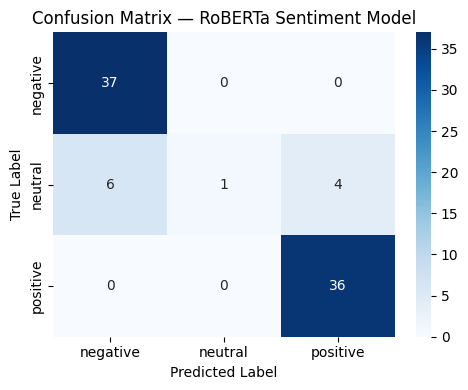

In [9]:
# ── CELL 5 — Confusion Matrix ──
cm = confusion_matrix(
    test_data['true_label'],
    test_data['predicted_label'],
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            cmap='Blues')
plt.title('Confusion Matrix — RoBERTa Sentiment Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

In [10]:
%pip install nltk.stem

ERROR: Could not find a version that satisfies the requirement nltk.stem (from versions: none)
ERROR: No matching distribution found for nltk.stem


In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [12]:
lemmatizer = WordNetLemmatizer() 
stop_words = set(stopwords.words('english'))
def clean_text(text):
    # 1. Sirf letters rakhna, baqi numbers aur punctuations hata dena
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 2. Sab aksharon ko chota (lowercase) karna aur lafzon mein torna (Tokenize)
    words = text.lower().split()
    
    # 3. Stopwords hatana aur Lemmatization karna
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    # 4. Dobara lafzon ko jor kar poora saaf sentence banana
    return " ".join(cleaned_words)
# Poore dataset ke text column par apply karna
df['cleaned_text'] = df['text'].apply(clean_text)
print("Text cleaning complete! Sample:")
print(df[['text', 'cleaned_text']].head(2))

NameError: name 'df' is not defined

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_text'])
y = df['sentiment_label']
print(f"Text converted to Numbers matrix. Shape of X: {X.shape}")

Text converted to Numbers matrix. Shape of X: (83, 1736)


In [ ]:
# ── CELL 9 — Handling Class Imbalance (SMOTE) ──
# Pehle check karein ke kiya hamare paas imbalanced-learn library install hai
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    %pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

from collections import Counter
print(f"SMOTE se pehle ka data distribution: {Counter(y)}")

# SMOTE ka object banana
smote = SMOTE(random_state=42)

# Data ko balance karna (Naye rows generate karna)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"SMOTE ke baad ka data distribution: {Counter(y_resampled)}")

SMOTE se pehle ka data distribution: Counter({'positive': 45, 'negative': 38})
SMOTE ke baad ka data distribution: Counter({'negative': 45, 'positive': 45})


In [ ]:
# ── CELL 10 — Train-Test Split ──
from sklearn.model_selection import train_test_split

# Data ko 80% training aur 20% testing mein torna
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42
)

print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")

Training data size: 72 samples
Testing data size: 18 samples


In [ ]:
# ── CELL 11 — Model Training & Cross-Validation ──
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Models ke khaali objects banana
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# 2. Naive Bayes par 5-Fold Cross Validation chalana
nb_cv_scores = cross_val_score(nb_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Naive Bayes CV Accuracy (5 Folds): {nb_cv_scores}")
print(f"Naive Bayes Mean CV Accuracy: {np.mean(nb_cv_scores)*100:.2f}%")

# 3. Dono models ko Asli data par Train (Fit) karna
lr_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)

# 4. Test data par final accuracy check karna
print(f"\nFinal Logistic Regression Test Accuracy: {lr_model.score(X_test, y_test)*100:.2f}%")
print(f"Final Naive Bayes Test Accuracy: {nb_model.score(X_test, y_test)*100:.2f}%")

Naive Bayes CV Accuracy (5 Folds): [0.6        0.73333333 0.85714286 0.71428571 0.78571429]
Naive Bayes Mean CV Accuracy: 73.81%

Final Logistic Regression Test Accuracy: 33.33%
Final Naive Bayes Test Accuracy: 55.56%


In [ ]:
# ── CELL 12 — Hyperparameter Tuning (GridSearchCV) ──
from sklearn.model_selection import GridSearchCV

# Naive Bayes ke 'alpha' parameter ke liye alag alag options dena
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]
}

# GridSearchCV ka automatic machine setup karna
grid_search = GridSearchCV(
    estimator=MultinomialNB(), 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy'
)

# Saare options ko chala kar test karna
grid_search.fit(X_train, y_train)

# Sab se best parameters aur unka result print karna
print(f"Best Configuration/Setting: {grid_search.best_params_}")
print(f"Best Tuned Accuracy on Train Set: {grid_search.best_score_*100:.2f}%")

# Best model ko nikal kar test set par final check karna
best_nb_model = grid_search.best_estimator_
print(f"Tuned Naive Bayes Test Accuracy: {best_nb_model.score(X_test, y_test)*100:.2f}%")

Best Configuration/Setting: {'alpha': 0.5}
Best Tuned Accuracy on Train Set: 82.19%
Tuned Naive Bayes Test Accuracy: 61.11%


In [ ]:
# ── CELL 14 — Model Saving (MLOps) ──
import joblib
import os

# Google Drive ka path set karna jahan models save honge
save_path = '/content/drive/MyDrive/saved_models/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 1. Traditional ML Model (Naive Bayes) ko save karna .pkl format mein
# joblib library kisi bhi python object ko file mein pack kar deti hai
joblib.dump(best_nb_model, os.path.join(save_path, 'naive_bayes_model.pkl'))
joblib.dump(tfidf, os.path.join(save_path, 'tfidf_vectorizer.pkl'))
print("Naive Bayes Model and TF-IDF saved as .pkl! 💾")

# 2. Deep Learning Model (Fine-Tuned RoBERTa) ko save karna
# Transformers ke models pure folder ki surat mein save hote hain jisme configuration hoti hai
model.save_pretrained(os.path.join(save_path, 'fine_tuned_roberta'))
tokenizer.save_pretrained(os.path.join(save_path, 'fine_tuned_roberta'))
print("Fine-tuned RoBERTa Model and Tokenizer saved successfully! 🤖")

Naive Bayes Model and TF-IDF saved as .pkl! 💾


NameError: name 'model' is not defined

In [ ]:
# Load karne ka tareeqa:
loaded_nb = joblib.load('/content/drive/MyDrive/saved_models/naive_bayes_model.pkl')
# Aur yeh bina training ke direct predict karne ke liye taiyar hoga!

NameError: name 'joblib' is not defined